# Set up

In [3]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [4]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

In [5]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

# 0-150ms

In [6]:
# Load LFP data
start_time = 0.0
end_time = 0.15
padding = 0.1
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


## Fit

In [26]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 10
penalty = 5e-1

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}

ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, warp_interval=[[0, 0.15]], verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    
    filter_list = model.get_filter(ci=True)
    for j in range(len(model.basis_list)):
        running_filter[i,j-1] = filter_list[j]
    output_list = model.get_filter_output(intermediate=False, ci=True)
    for j in range(len(model.basis_list)):
        running_output[i,j-1] = output_list[j]
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, warp_interval=[[0, 0.15]], verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    
    filter_list = model.get_filter(ci=True)
    for j in range(len(model.basis_list)):
        stationary_filter[i,j-1] = filter_list[j]
    output_list = model.get_filter_output(intermediate=False, ci=True)
    for j in range(len(model.basis_list)):
        stationary_output[i,j-1] = output_list[j]
    
    # for effect filter
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI_filter[filter_index], statistics_filter[filter_index] = GLM.get_excursion_statistic(function1, function2)
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI_filter[filter_index], statistics_filter[filter_index] = GLM.get_excursion_statistic(function1, function2)
    
    # for effect output
    filter_index = i,-1
    function1 = np.exp( running_output[filter_index][0] )
    function2 = np.exp( stationary_output[filter_index][0] )
    ROI_output[filter_index], statistics_output[filter_index] = GLM.get_excursion_statistic(function1, function2)
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_output[filter_index][0]
        function2 = stationary_output[filter_index][0]
        ROI_output[filter_index], statistics_output[filter_index] = GLM.get_excursion_statistic(function1, function2)

aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
baseline_aic = 570714.232742189
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
baseline_bic = 588924.4932276756
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")
    

6it [01:19, 13.18s/it]

AIC improvement of the model is: 402707.46729637193
BIC improvement of the model is: 408292.2779740206


/home/qix/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

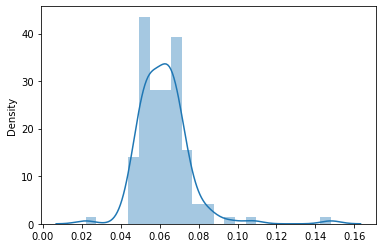

In [27]:
sns.distplot(stationary_model_list[2].shifts[:,1])

## Plot filters

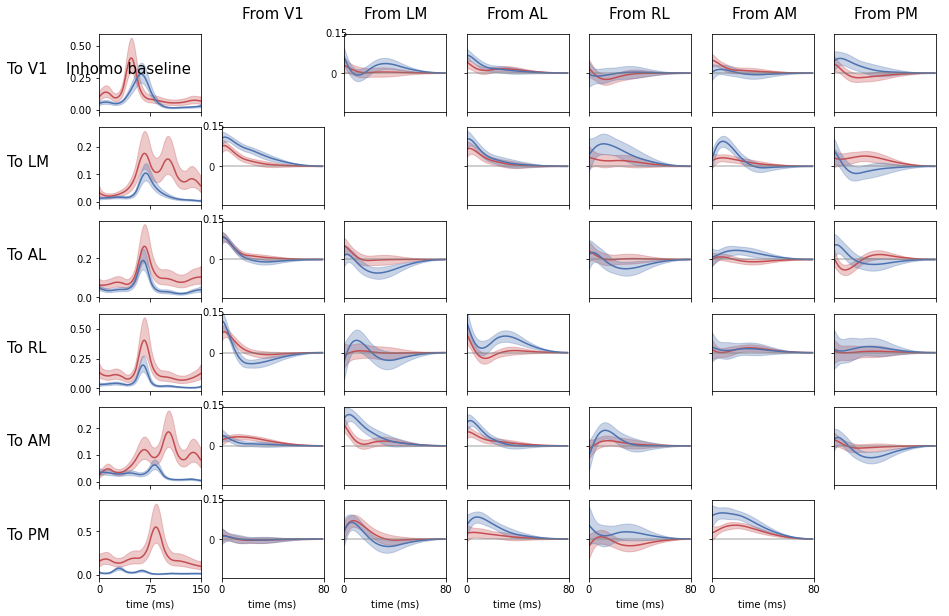

In [28]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=True, 
                              plot_self=False, output=False)

## Plot the filter outputs

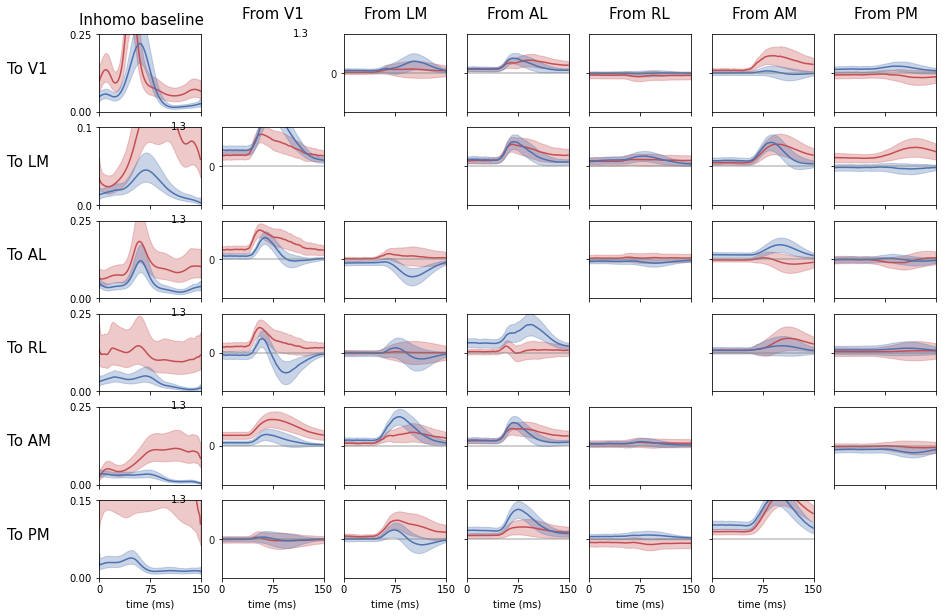

In [29]:
GLM.plot_output_with_excursion(V1, stationary_output, running_output, inference=False, 
                              output=False)